In [2]:
import pandas as pd

# Load the dataset (skipping empty extra columns if present)
df = pd.read_csv('Pakistan Largest Ecommerce Dataset.csv', low_memory=False)

# See how many rows and columns exist
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

# Show the first 5 rows
df.head()

Total Rows: 1,048,575
Total Columns: 26


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [3]:
# 1. Keep only the columns that actually matter for business insights
cols_to_keep = [
    'item_id', 'status', 'created_at', 'price',
    'qty_ordered', 'grand_total', 'category_name_1',
    'payment_method', 'Customer ID'
]

# Filter down to these columns (drops all those trailing empty Unnamed columns)
df_clean = df[cols_to_keep].copy()

# 2. Drop rows where critical info is completely missing
df_clean = df_clean.dropna(subset=['Customer ID', 'status', 'grand_total', 'created_at'])

# 3. Clean up the status column text (make everything lowercase and strip extra spaces)
df_clean['status'] = df_clean['status'].astype(str).str.strip().str.lower()

# 4. Standardize Payment Methods (group minor typos/variations into clean names)
def clean_payment(method):
    method = str(method).strip().lower()
    if 'cod' in method or 'cash' in method:
        return 'Cash on Delivery'
    elif 'easypay' in method:
        return 'Easypaisa'
    elif 'jazz' in method:
        return 'JazzCash'
    elif 'bank' in method or 'card' in method or 'mcbl' in method or 'ubl' in method:
        return 'Bank / Card'
    else:
        return 'Other'

df_clean['payment_method_clean'] = df_clean['payment_method'].apply(clean_payment)

# 5. Clean up date format
df_clean['created_at'] = pd.to_datetime(df_clean['created_at'], errors='coerce')

# Check the cleaned result
print(f"Cleaned Rows Remaining: {len(df_clean):,}")
df_clean.head(3)

Cleaned Rows Remaining: 584,498


,item_id,status,created_at,price,qty_ordered,grand_total,category_name_1,payment_method,Customer ID,payment_method_clean
0,211131.0,complete,2016-07-01,1950.0,1.0,1950.0,Women's Fashion,cod,1.0,Cash on Delivery
1,211133.0,canceled,2016-07-01,240.0,1.0,240.0,Beauty & Grooming,cod,2.0,Cash on Delivery
2,211134.0,canceled,2016-07-01,2450.0,1.0,2450.0,Women's Fashion,cod,3.0,Cash on Delivery


In [4]:
# 1. Classify orders into simple outcomes: Completed, Canceled, or In-Progress/Other
def categorize_status(status):
    if status in ['complete', 'received', 'paid', 'closed']:
        return 'Completed'
    elif status in ['canceled', 'order_refunded', 'fraud']:
        return 'Canceled'
    else:
        return 'Other'

df_clean['order_outcome'] = df_clean['status'].apply(categorize_status)

# 2. Filter to finalized orders (Completed vs Canceled)
finalized_orders = df_clean[df_clean['order_outcome'].isin(['Completed', 'Canceled'])]

# 3. Calculate total volume and cancellation % by payment method
payment_analysis = pd.crosstab(
    finalized_orders['payment_method_clean'],
    finalized_orders['order_outcome'],
    normalize='index'
) * 100

# Add order counts
payment_analysis['Total Orders'] = finalized_orders['payment_method_clean'].value_counts()
payment_analysis['Completed (%)'] = payment_analysis['Completed'].round(1)
payment_analysis['Canceled (%)'] = payment_analysis['Canceled'].round(1)

# Display clean table sorted by volume
summary_table = payment_analysis[['Total Orders', 'Completed (%)', 'Canceled (%)']].sort_values(by='Total Orders', ascending=False)
summary_table

order_outcome,Total Orders,Completed (%),Canceled (%)
payment_method_clean,,,
Cash on Delivery,264187,73.3,26.7
Easypaisa,126950,39.5,60.5
Other,106994,36.0,64.0
JazzCash,50356,47.1,52.9
Bank / Card,24918,26.8,73.2


In [5]:
# 1. Filter only for successfully completed orders
completed_orders = df_clean[df_clean['order_outcome'] == 'Completed']

# 2. Count completed orders per unique customer
orders_per_customer = completed_orders.groupby('Customer ID')['item_id'].nunique()

# 3. Categorize into One-Time vs Repeat Buyers
buyer_type = orders_per_customer.apply(lambda x: 'One-Time Buyer (1 order)' if x == 1 else 'Repeat Buyer (2+ orders)')

# 4. Calculate total counts and percentages
retention_summary = buyer_type.value_counts().reset_index()
retention_summary.columns = ['Buyer Type', 'Total Customers']
retention_summary['Percentage (%)'] = (retention_summary['Total Customers'] / retention_summary['Total Customers'].sum() * 100).round(1)

retention_summary

,Buyer Type,Total Customers,Percentage (%)
0,Repeat Buyer (2+ orders),40178,50.4
1,One-Time Buyer (1 order),39597,49.6


In [6]:
# 1. Clean category names (remove trailing whitespace and NaN)
df_clean['category_name_1'] = df_clean['category_name_1'].fillna('Unknown').astype(str).str.strip()

# 2. Filter completed orders for category revenue
completed_df = df_clean[df_clean['order_outcome'] == 'Completed']

# 3. Calculate metrics per category: Completed Orders, Total Revenue, Average Order Value (AOV)
category_perf = completed_df.groupby('category_name_1').agg(
    Completed_Orders=('item_id', 'count'),
    Total_Revenue_PKR=('grand_total', 'sum')
).reset_index()

category_perf['AOV_PKR'] = (category_perf['Total_Revenue_PKR'] / category_perf['Completed_Orders']).round(0)
category_perf['Revenue_Share (%)'] = (category_perf['Total_Revenue_PKR'] / category_perf['Total_Revenue_PKR'].sum() * 100).round(1)

# Sort by Total Revenue (top 10 categories)
top_categories = category_perf.sort_values(by='Total_Revenue_PKR', ascending=False).head(10)
top_categories

,category_name_1,Completed_Orders,Total_Revenue_PKR,AOV_PKR,Revenue_Share (%)
9,Mobiles & Tablets,50133,6.124541e+08,12217.0,37.8
0,Appliances,25431,2.356589e+08,9267.0,14.5
4,Entertainment,11473,1.925146e+08,16780.0,11.9
15,Women's Fashion,33988,1.422328e+08,4185.0,8.8
8,Men's Fashion,52652,8.681892e+07,1649.0,5.4
13,Superstore,27021,6.034079e+07,2233.0,3.7
10,Others,9247,5.869160e+07,6347.0,3.6
1,Beauty & Grooming,27162,4.901535e+07,1805.0,3.0
3,Computing,7191,4.874692e+07,6779.0,3.0
6,Home & Living,15847,4.058747e+07,2561.0,2.5


/tmp/ipykernel_1628/3163950613.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1628/3163950613.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


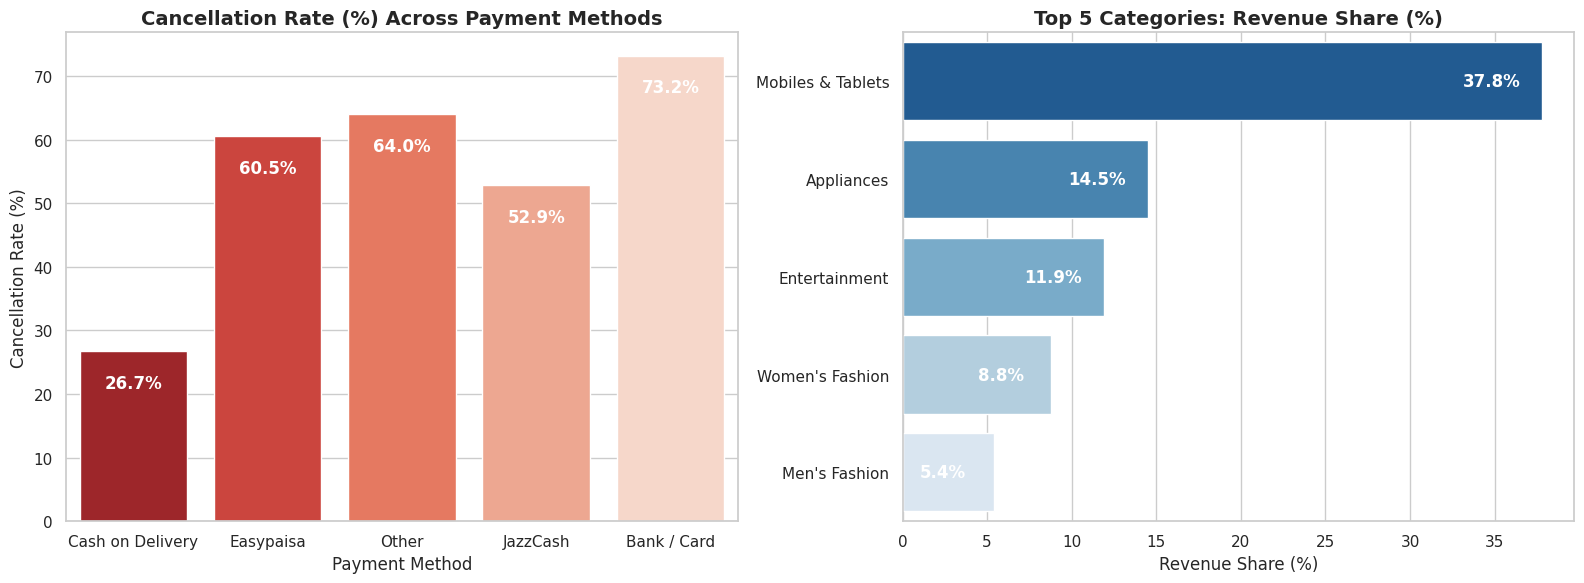

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Cancellation Rate by Payment Method
sns.barplot(
    data=summary_table.reset_index(),
    x='payment_method_clean',
    y='Canceled (%)',
    palette='Reds_r',
    ax=axes[0]
)
axes[0].set_title('Cancellation Rate (%) Across Payment Methods', fontsize=14, weight='bold')
axes[0].set_xlabel('Payment Method', fontsize=12)
axes[0].set_ylabel('Cancellation Rate (%)', fontsize=12)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                    ha='center', va='center', color='white', weight='bold')

# Chart 2: Top 5 Categories by Revenue Contribution
top_5_cats = top_categories.head(5)
sns.barplot(
    data=top_5_cats,
    x='Revenue_Share (%)',
    y='category_name_1',
    palette='Blues_r',
    ax=axes[1]
)
axes[1].set_title('Top 5 Categories: Revenue Share (%)', fontsize=14, weight='bold')
axes[1].set_xlabel('Revenue Share (%)', fontsize=12)
axes[1].set_ylabel('')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.1f}%",
                    (p.get_width() - 3, p.get_y() + p.get_height() / 2.),
                    ha='center', va='center', color='white', weight='bold')

plt.tight_layout()
plt.savefig('ecommerce_key_insights.png', dpi=300)
plt.show()